# Comparison of Country Ranking with JTM Funding
Felix Zaussinger | 06.11.2023

**Core Analysis Goal(s)**
1. Read and visualize JTM Funding from JTF and TJTPs
2. Run correlation analysis between rel/abs employment shares and funding allocation
3.

**Key Insight(s)**
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import geopandas as gpd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import pingouin as pg

# needed for relative import in jupyter lab
module_path = os.path.abspath(os.path.join(os.pardir, os.pardir))
if module_path not in sys.path:
    sys.path.append(module_path)

from src import utils, plotting_utils, stats_utils
from src.visualization.visualize import EulfsVis
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

C:\Users\fzaussinger.D\AppData\Local\miniconda3\envs\re4gt2\Lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.4.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## Read data

In [2]:
df_jtf_raw = pd.read_excel(
    os.path.join(useful_paths.data_raw, 'eu-jtf', '2021-2027_JTF_Finances_Details_20231106_utf8.xlsx'),
    sheet_name='DataReformattedUTF8'
)

df_jtf_homepage = pd.read_excel(
    os.path.join(useful_paths.data_raw, 'eu-jtf', '2021-2027_JTF_Finances_Details_20231106_utf8.xlsx'),
    sheet_name='DataHomepage'
)

lfs_country_data_raw = pd.read_csv(os.path.join(useful_paths.figure_dir, '03_eulfs', '2019', 'employment_shares_by_country', 'transition_risk_indicator.csv'), index_col=0)

In [3]:
df_jtf_raw

,ms,ms_name_en,CCI,programme_title_short,status,version,last_adoption_date_ecms,priority_code,priority_name,region_chatgpt_pn,region_final,policy_objective_short_name,policy_objective_code,policy_objective_name,specific_objective_short_name,specific_objective_code,specific_objective_name,dimension_type,category_title_short,category_code,category_name,fund,category_of_region,cofinancing_rate,eu_amount,total_amount,climate_weighting,eu_climate_amount,total_climate_amount,environmental_weighting,eu_environmental_amount,total_environmental_amount,biodiversity_weighting,eu_biodiversity_amount,total_biodiversity_amount,gender_weighting,eu_gender_amount,total_gender_amount,clean_air_weighting,eu_clean_air_amount,total_clean_air_amount,sustainable_urban_development,territorial_tool,territory_type,un_sdg_tracking
0,AT,Austria,2021AT05FFPR001,Employment - AT - ESF+/JTF,Adopted by EC,1.00,2022-11-11,7,JTF,(not found),NaN,PO8 JTF specific objective,8,JTF specific objective,JSO8.1 Just Transition Fund,JSO8.1,Just Transition Fund,Intervention Field,999 Flat rate technical assistance,999,Flat rate technical assistance – Article 36 (5...,JTF,JTF,0.50,"2,297,633.00","4,595,266.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AT,Austria,2021AT05FFPR001,Employment - AT - ESF+/JTF,Adopted by EC,1.00,2022-11-11,7,JTF,(not found),NaN,PO8 JTF specific objective,8,JTF specific objective,JSO8.1 Just Transition Fund,JSO8.1,Just Transition Fund,Form of Support,01 grant,1,Grant,JTF,JTF,0.50,"57,440,845.00","114,881,690.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AT,Austria,2021AT05FFPR001,Employment - AT - ESF+/JTF,Adopted by EC,1.00,2022-11-11,7,JTF,NaN,NaN,PO8 JTF specific objective,8,JTF specific objective,JSO8.1 Just Transition Fund,JSO8.1,Just Transition Fund,Intervention Field,140 Labour market matching and transitions,140,Support for labour market matching and transit...,JTF,JTF,0.50,"57,440,845.00","114,881,690.00",1.00,"57,440,845.00","114,881,690.00",0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,SDG 8 Decent work and economic growth
3,AT,Austria,2021AT05FFPR001,Employment - AT - ESF+/JTF,Adopted by EC,1.00,2022-11-11,7,JTF,NaN,NaN,PO8 JTF specific objective,8,JTF specific objective,JSO8.1 Just Transition Fund,JSO8.1,Just Transition Fund,Territorial delivery mechanism / territorial f...,24 Other territorial: Other types of territori...,24,Other type of territorial tool - Other types o...,JTF,JTF,0.50,"57,440,845.00","114,881,690.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Non-SUD,Other territorial tool,Other territorial targeting,SDG 11 Sustainable cities and communities
4,AT,Austria,2021AT05FFPR001,Employment - AT - ESF+/JTF,Adopted by EC,1.00,2022-11-11,7,JTF,NaN,NaN,PO8 JTF specific objective,8,JTF specific objective,JSO8.1 Just Transition Fund,JSO8.1,Just Transition Fund,Gender Equality,02 Gender mainstreaming,2,Gender mainstreaming,JTF,JTF,0.50,"57,440,845.00","114,881,690.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,"22,976,338.00","45,952,676.00",NaN,NaN,NaN,NaN,NaN,NaN,SDG 5 Achieve gender equality and empower all ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,SK,Slovakia,2021SK16FFPR001,Programme Slovakia – SK– ERDF/CF/JTF/ESF+,Adopted by EC,1.20,2022-11-24,7P4,Technická pomoc FST,(not found),NaN,POTA Technical Assistance,TA,Technical Assistance,TA Technical Assistance,TA,Technical Assistance,Gender Equality,03 Gender neutral,3,Gender neutral,JTF,JTF,0.75,"18,360,759.00","24,481,013.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1465,SK,Slovakia,2021SK16FFPR001,Programme Slovakia – SK– ERDF/CF/JTF/ESF+,Adopted by EC,1.20,2022-11-24,7P4,Technická pomoc FST,NaN,NaN,POTA Technical Assistance,TA,Technical Assistance,TA Technical Assistance,TA,Technic

## Preprocessing

Sums based on raw data do not add up to sums from homepage...
- copied tabular data from homepage on 6.11.2023
- source: https://cohesiondata.ec.europa.eu/stories/s/28yb-762c
- table 1: Just Transition fund - EU and total investment 21-27

In [4]:
sums_from_raw = df_jtf_raw.groupby('ms')[['eu_amount', 'total_amount']].sum()

In [5]:
# calculate country contributions
df_jtf_homepage['country_amount'] = df_jtf_homepage['total_amount'] - df_jtf_homepage['eu_amount']
df_jtf_homepage

,ms,eu_amount,total_amount,country_amount
0,PL,3847346473,"4,777,482,256.18","930,135,783.18"
1,DE,2477674410,"4,044,170,633.98","1,566,496,223.98"
2,RO,2139715532,"2,530,738,056.95","391,022,524.95"
3,CZ,1641492008,"1,931,167,073.08","289,675,065.08"
4,FR,1029952599,"2,112,628,023.00","1,082,675,424.00"
5,EL,1375059412,"1,629,187,543.07","254,128,131.07"
6,IT,1029588558,"1,211,280,659.06","181,692,101.06"
7,ES,868744863,"1,255,311,029.97","386,566,166.97"
8,NL,623103298,"1,246,206,602.13","623,103,304.13"
9,FI,465677790,"665,253,987.05","199,576,197.05"


Prepare country level employment from LFS analysis

In [6]:
lfs_country_data = lfs_country_data_raw.copy()

rename_dict = {
    'FFPO': 'high-carbon',
    'FFPOTC': 'hard-to-abate',
    'Green': 'low-carbon'
}

lfs_country_data.Pool = lfs_country_data.Pool.replace(rename_dict)
lfs_country_data_red = lfs_country_data.loc[lfs_country_data.Pool != 'CPO', ['COUNTRYW', 'Pool', 'employment_relative', 'employment_absolute']]
lfs_country_data_red.head()

,COUNTRYW,Pool,employment_relative,employment_absolute
1,DE,high-carbon,3.61,"1,506,568.44"
2,DE,hard-to-abate,1.43,"596,274.52"
3,DE,low-carbon,2.08,"866,581.70"
5,IT,high-carbon,3.53,"808,979.14"
6,IT,hard-to-abate,1.09,"250,332.43"


number of countries part of country level transition risk analysis

In [7]:
lfs_country_data_red.COUNTRYW.unique().shape

(27,)

Merge datasets

In [8]:
df_merged = pd.merge(
    lfs_country_data_red,
    df_jtf_homepage,
    left_on='COUNTRYW',
    right_on='ms',
    how='outer'
)

Calculate Euro / jobs (high-carbon, hard-to-abate)

In [9]:
df_merged['total_amount_per_job'] = df_merged['total_amount'] / df_merged['employment_absolute']
df_merged['eu_amount_per_job'] = df_merged['eu_amount'] / df_merged['employment_absolute']
df_merged['country_amount_per_job'] = df_merged['country_amount'] / df_merged['employment_absolute']

In [10]:
df_merged.COUNTRYW.unique().shape

(28,)

In [11]:
df_merged[['total_amount_per_job', 'eu_amount_per_job', 'country_amount_per_job']].describe().to_csv(
    os.path.join(useful_paths.figure_dir, 'eu-jtf', '2021-2027_JTF_Finances_Employment_Descriptives_short.csv')
)

df_merged[['total_amount_per_job', 'eu_amount_per_job', 'country_amount_per_job']].describe()

,total_amount_per_job,eu_amount_per_job,country_amount_per_job
count,66.00,66.00,66.00
mean,"11,299.21","7,848.28","3,450.93"
std,"11,470.66","8,330.36","3,891.30"
min,"1,314.06","1,091.03",197.11
25%,"3,767.47","2,182.12","1,281.25"
50%,"7,153.28","4,184.37","2,327.63"
75%,"15,330.83","11,614.96","3,701.63"
max,"64,475.22","39,082.16","25,393.06"


In [12]:
df_merged.to_csv(
    os.path.join(useful_paths.figure_dir, 'eu-jtf', '2021-2027_JTF_Finances_Employment_Merged.csv')
)

Calculate descriptive statistics and save results

In [13]:
df_merged_descriptives = df_merged.groupby("Pool").describe()
df_merged_descriptives.to_csv(
    os.path.join(useful_paths.figure_dir, 'eu-jtf', '2021-2027_JTF_Finances_Employment_Descriptives.csv')
)

In [14]:
df_merged_descriptives

employment_relative                                     \
                            count mean  std  min  25%  50%  75%  max   
Pool                                                                   
hard-to-abate               27.00 1.05 0.24 0.65 0.87 1.02 1.22 1.50   
high-carbon                 27.00 2.91 1.17 1.40 1.99 2.80 3.57 5.71   
low-carbon                  27.00 2.08 0.43 1.49 1.79 2.01 2.36 3.13   

              employment_absolute                                           \
                            count       mean        std      min       25%   
Pool                                                                         
hard-to-abate               27.00  85,122.81 130,097.87 1,538.44 18,002.59   
high-carbon                 27.00 228,730.80 335,633.57 3,818.78 44,557.49   
low-carbon                  27.00 155,199.44 210,344.68 3,730.24 33,832.62   

                                                 eu_amount                 \
                     50%        75%          max     count           mean   
Pool                                                                        
hard-to-abate  39,242.58  70,032.66   596,274.52     22.00 590,111,028.18   
high-carbon   111,693.41 265,060.15 1,506,568.44     22.00 590,111,028.18   
low-carbon     85,002.87 126,089.46   866,581.70     22.00 590,111,028.18   

                                                                         \
                         std          min            25%            50%   
Pool                                                                      
hard-to-abate 687,745,744.32 9,264,483.00 162,459,657.50 267,156,308.50   
high-carbon   687,745,744.32 9,264,483.00 162,459,657.50 267,156,308.50   
low-carbon    687,745,744.32 9,264,483.00 162,459,657.50 267,156,308.50   

                                              total_amount                 \
                         75%              max        count           mean   
Pool                                                                        
hard-to-abate 807,334,471.75 2,477,674,410.00        22.00 871,126,207.88   
high-carbon   807,334,471.75 2,477,674,410.00        22.00 871,126,207.88   
low-carbon    807,334,471.75 2,477,674,410.00        22.00 871,126,207.88   

                                                                          \
                         std           min            25%            50%   
Pool                                                                       
hard-to-abate 997,997,536.38 18,528,966.00 240,179,088.52 388,997,883.00   
high-carbon   997,997,536.38 18,528,966.00 240,179,088.52 388,997,883.00   
low-carbon    997,997,536.38 18,528,966.00 240,179,088.52 388,997,883.00   

                                                country_amount                 \
                           75%              max          count           mean   
Pool                                                                            
hard-to-abate 1,237,475,116.36 4,044,170,633.98          22.00 281,015,179.69   
high-carbon   1,237,475,116.36 4,044,170,633.98          22.00 281,015,179.69   
low-carbon    1,237,475,116.36 4,044,170,633.98          22.00 281,015,179.69   

                                                                        \
                         std          min           25%            50%   
Pool                                                                     
hard-to-abate 376,522,744.92 9,264,483.00 53,999,678.49 168,718,203.53   
high-carbon   376,522,744.92 9,264,483.00 53,999,678.49 168,718,203.53   
low-carbon    376,522,744.92 9,264,483.00 53,999,678.49 168,718,203.53   

                                              total_amount_per_job            \
                         75%              max                count      mean   
Pool                                                                           
hard-to-abate 285,733,440.81 1,566,496,223.98                22.00 17,738.87   
high-carbon   285,733,440.

In [15]:
categories = df_merged.Pool.dropna().unique()
categories

array(['high-carbon', 'hard-to-abate', 'low-carbon'], dtype=object)

#### Create table with relative exposure and spending per hard to abate job for updated figure 5

In [ ]:
df_merged

## Modelling

#### Correlate employment with JTF spending

**Results**
1) Relative employment: we only find significant correlations between employment shares and EU or total spending for the hard-to-abate category (EU: r=0.5, p=0.02: Total: r=0.44, p=0.04). Intuitively, this makes sense, as we expect regions and countries with higher concentrations of hard-to-abate employment to apply for funds, and the EC to grant those with priority.
2) Absolute employment: correlations are positive and significant (0.73 < r < 0.86) across all 3 categories. This simply reflects larger countries are applying for and eligible for more funds.

In [16]:
results = []
cols = [['employment_relative', "employment_absolute"], ["eu_amount", "total_amount", "country_amount"]]

for category in categories:
    dfp = df_merged.loc[df_merged.Pool == category]
    corr = pg.pairwise_corr(data=dfp, columns=cols)
    corr['category'] = category
    results.append(corr)

df_results = pd.concat(results)

In [17]:
df_results

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power,category
0,employment_relative,eu_amount,pearson,two-sided,22,0.36,"[-0.07, 0.68]",0.10,0.944,0.39,high-carbon
1,employment_relative,total_amount,pearson,two-sided,22,0.25,"[-0.19, 0.61]",0.25,0.489,0.21,high-carbon
2,employment_relative,country_amount,pearson,two-sided,22,0.02,"[-0.41, 0.44]",0.94,0.265,0.05,high-carbon
3,employment_absolute,eu_amount,pearson,two-sided,22,0.78,"[0.53, 0.9]",0.00,1363.392,1.00,high-carbon
4,employment_absolute,total_amount,pearson,two-sided,22,0.86,"[0.68, 0.94]",0.00,4.251e+04,1.00,high-carbon
5,employment_absolute,country_amount,pearson,two-sided,22,0.84,"[0.65, 0.93]",0.00,2.154e+04,1.00,high-carbon
0,employment_relative,eu_amount,pearson,two-sided,22,0.50,"[0.1, 0.76]",0.02,3.864,0.69,hard-to-abate
1,employment_relative,total_amount,pearson,two-sided,22,0.44,"[0.02, 0.72]",0.04,1.844,0.55,hard-to-abate
2,employment_relative,country_amount,pearson,two-sided,22,0.24,"[-0.2, 0.6]",0.29,0.451,0.19,hard-to-abate
3,employment_absolute,eu_amount,pearson,two-sided,22,0.77,"[0.51, 0.9]",0.00,873.055,0.99,hard-to-abate


In [18]:
# save results
df_results.to_csv(
    os.path.join(useful_paths.figure_dir, 'eu-jtf', '2021-2027_JTF_Finances_Employment_Correlations.csv')
)

## Visualisation

#### Maps

1. EU Funds allocated per high-carbon and hard-to-abate job (Euro / job)
2. Total Funds allocated per high-carbon and hard-to-abate job (Euro / job)

In [19]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"
config_model = "model_config.yml"
config_vis = "vis_config.yml"

vis = EulfsVis(
    fn_config_path=config_paths,
    fn_config_data=config_data,
    fn_vis_config=config_vis
)

join geodata to df

In [20]:
gdf_nuts = vis.gdf_nuts['3035']
gdf_nuts_0 = gdf_nuts.loc[gdf_nuts["LEVL_CODE"] == 0]

gdf_dict = {}
for category in categories:
    gdf_merged = pd.merge(
        df_merged[df_merged.Pool == category],
        gdf_nuts_0,
        left_on='ms',
        right_on='NUTS_ID',
        how='right'
    )
    
    gdf_dict[category] = gpd.GeoDataFrame(gdf_merged)

In [21]:
gdf_nuts_0.NUTS_ID.unique().shape

(37,)

In [22]:
gdf_dict['hard-to-abate']

,COUNTRYW,Pool,employment_relative,employment_absolute,ms,eu_amount,total_amount,country_amount,total_amount_per_job,eu_amount_per_job,country_amount_per_job,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,FID,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BG,0,BG,Bulgaria,България,0.00,NaN,0,BG,"POLYGON ((5363358.686 2390534.464, 5368040.621..."
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0.00,NaN,0,CH,"POLYGON ((4217105.160 2744025.879, 4218081.206..."
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,0,AL,Shqipëria,Shqipëria,0.00,NaN,0,AL,"MULTIPOLYGON (((5129579.170 2204098.752, 51302..."
3,CZ,hard-to-abate,1.50,"78,027.78",CZ,"1,641,492,008.00","1,931,167,073.08","289,675,065.08","24,749.74","21,037.28","3,712.46",CZ,0,CZ,Česko,Česko,0.00,NaN,0,CZ,"POLYGON ((4635755.041 3113254.655, 4636696.907..."
4,BE,hard-to-abate,0.97,"45,333.87",BE,"182,605,712.00","456,514,280.00","273,908,568.00","10,070.05","4,028.02","6,042.03",BE,0,BE,Belgique/België,Belgique/België,0.00,NaN,0,BE,"MULTIPOLYGON (((3980658.913 3157888.224, 39782..."
5,AT,hard-to-abate,0.96,"40,836.04",AT,"135,769,268.00","284,456,990.09","148,687,722.09","6,965.83","3,324.74","3,641.09",AT,0,AT,Österreich,Österreich,0.00,NaN,0,AT,"POLYGON ((4726983.640 2881333.193, 4732277.939..."
6,DE,hard-to-abate,1.43,"596,274.52",DE,"2,477,674,410.00","4,044,170,633.98","1,566,496,223.98","6,782.40","4,155.26","2,627.14",DE,0,DE,Deutschland,Deutschland,0.00,NaN,0,DE,"MULTIPOLYGON (((4264045.786 3530123.440, 42682..."
7,CY,hard-to-abate,0.91,"3,706.44",CY,"101,113,715.00","144,448,166.00","43,334,451.00","38,972.25","27,280.57","11,691.67",CY,0,CY,Kýpros,Κύπρος,0.00,NaN,0,CY,"POLYGON ((6474836.157 1660347.267, 6470431.626..."
8,DK,hard-to-abate,0.79,"21,382.96",DK,"88,968,963.00","177,937,926.00","88,968,963.00","8,321.48","4,160.74","4,160.74",DK,0,DK,Danmark,Danmark,0.00,NaN,0,DK,"MULTIPOLYGON (((4650903.996 3591264.774, 46505..."
9,EE,hard-to-abate,1.39,"9,055.19",EE,"353,896,282.00","583,835,244.96","229,938,962.96","64,475.22","39,082.16","25,393.06",EE,0,EE,Eesti,Eesti,0.00,NaN,0,EE,"MULTIPOLYGON (((5209290.379 4151086.253, 52110..."


In [23]:
# indicators to plot
cols_to_plot = ['total_amount_per_job', 'eu_amount_per_job', 'country_amount_per_job']

# choose employment category 
category = 'high-carbon' # 'hard-to-abate'

# results directory
out_dir = os.path.join(useful_paths.figure_dir, 'eu-jtf', category)
utils.ccdir(out_dir)

vis.plot_map(
    gdf_sub=gdf_dict[category],
    cols_to_plot=cols_to_plot,
    save_data=True,
    out_dir=out_dir,
    figsize=(10,7),
    cbar_label='JTF Funding, € (2021-2027)',
    legend='None',
    n_cats=10,
    cmap='viridis',
    vmin=0,
    vmax=12500, # 50000
    cmap_set_over='orange',
    additional_title_info=category
)

total_amount_per_job
eu_amount_per_job
country_amount_per_job


#### Check how many JTF entries can be geolocated automatically
- Version 1: with raw data - column "priority_name"
- Version 2: with manually/gpt coded entries (12.02.2024) - column "region_final"
- Version 3: with manually/gpt coded entries (12.02.2024) - column "region_final" - 2nd iteration

In [24]:
from tqdm import tqdm

column = "region_final" # or "priority_name"

r = []
g = []
for region in tqdm(df_jtf_raw[column]):
    geo = gdf_nuts.loc[gdf_nuts.loc[:, "NUTS_NAME"] == region]

    r.append(region)
    g.append(geo)

g_bool = [False if s.empty else True for s in g]

# combine to df
results = pd.DataFrame(np.unique(g_bool, return_counts=True)).transpose().set_index(0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1469/1469 [00:01<00:00, 1154.99it/s]


In [25]:
results

,1
0,
False,386
True,1083


In [26]:
results / len(df_jtf_raw[column])

,1
0,
False,0.26
True,0.74


In [27]:
# add to table
df_jtf_raw["geolocated_region"] = g_bool

df_jtf_raw.to_excel(
    os.path.join(useful_paths.data_raw, 'eu-jtf', '2021-2027_JTF_Finances_Details_20231106_utf8_geolocations.xlsx')
)

**Result**
- Version 1: Before manual/gpt-assisted coding, we can geolocate 18% of entries (n=258). We would need to manually code the regions for 1211 entries.
- Version 2: After manual/gpt-assisted coding, we can geolocate 42% of entries (n=622).
- Version 3: After 2nd iteration, we can geolocate 74% of entries (n=1083).
- The remaining entries can only be mapped to countries (not to regions).

**What percentage of total investment do we capture?**
- 75.5%

In [28]:
total_amount_missing = df_jtf_raw.loc[df_jtf_raw["geolocated_region"] == False].total_amount.sum()
total_amount = df_jtf_raw.total_amount.sum()

1 - (total_amount_missing / total_amount)

0.7547461586910524

Non-related: Export shapefile as excel

In [29]:
pd.DataFrame(gdf_nuts).to_excel(
    os.path.join(useful_paths.figure_dir, 'eu-jtf', 'EU_shapefile_nuts_0123.xlsx')
)

#### Merge JTF and geodata files
1. 75% of entries that we can match: regional funding allocation
2. 25% of entries that we can't match: distribute across all regions weighted by population (take from EU LFS) 

In [39]:
gdf_jtf_raw = pd.merge(
    df_jtf_raw,
    gdf_nuts[["NUTS_ID", "NUTS_NAME", "LEVL_CODE", "geometry"]],
    left_on="region_final",
    right_on="NUTS_NAME",
    how="left"
)

In [95]:
assert np.isclose(gdf_jtf_raw["total_amount"] * gdf_jtf_raw["cofinancing_rate"], gdf_jtf_raw["eu_amount"]).sum() == gdf_jtf_raw.shape[0]

In [93]:
gdf_jtf_raw["country_amount"] = gdf_jtf_raw["total_amount"] - gdf_jtf_raw["eu_amount"]

In [96]:
# reduce columns to essential ones
cols2keep = [
    'ms', 'ms_name_en', 'programme_title_short', 'priority_name', 'region_final', 'total_amount', 'country_amount', 'eu_amount',
    'NUTS_ID', 'NUTS_NAME', 'LEVL_CODE', 'geometry'
]

gdf_jtf_raw_2 = gdf_jtf_raw[cols2keep]

#### Calculate regional sums for matched entries
- TODO: matching to several NUTS categories (1-3) creates duplicate entries

In [114]:
regional_inv = gdf_jtf_raw_2.loc[~gdf_jtf_raw_2["region_final"].isna()]
gdf_regional_inv = regional_inv.groupby(['NUTS_NAME', 'NUTS_ID', 'geometry']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum}).reset_index()
gdf_regional_inv = gpd.GeoDataFrame(gdf_regional_inv)

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\918879297.py:2: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  gdf_regional_inv = regional_inv.groupby(['NUTS_NAME', 'NUTS_ID', 'geometry']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum}).reset_index()
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\918879297.py:2: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  gdf_regional_inv = regional_inv.groupby(['NUTS_NAME', 'NUTS_ID', 'geometry']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum}).reset_index()


total_amount


AttributeError: 'NoneType' object has no attribute 'split'

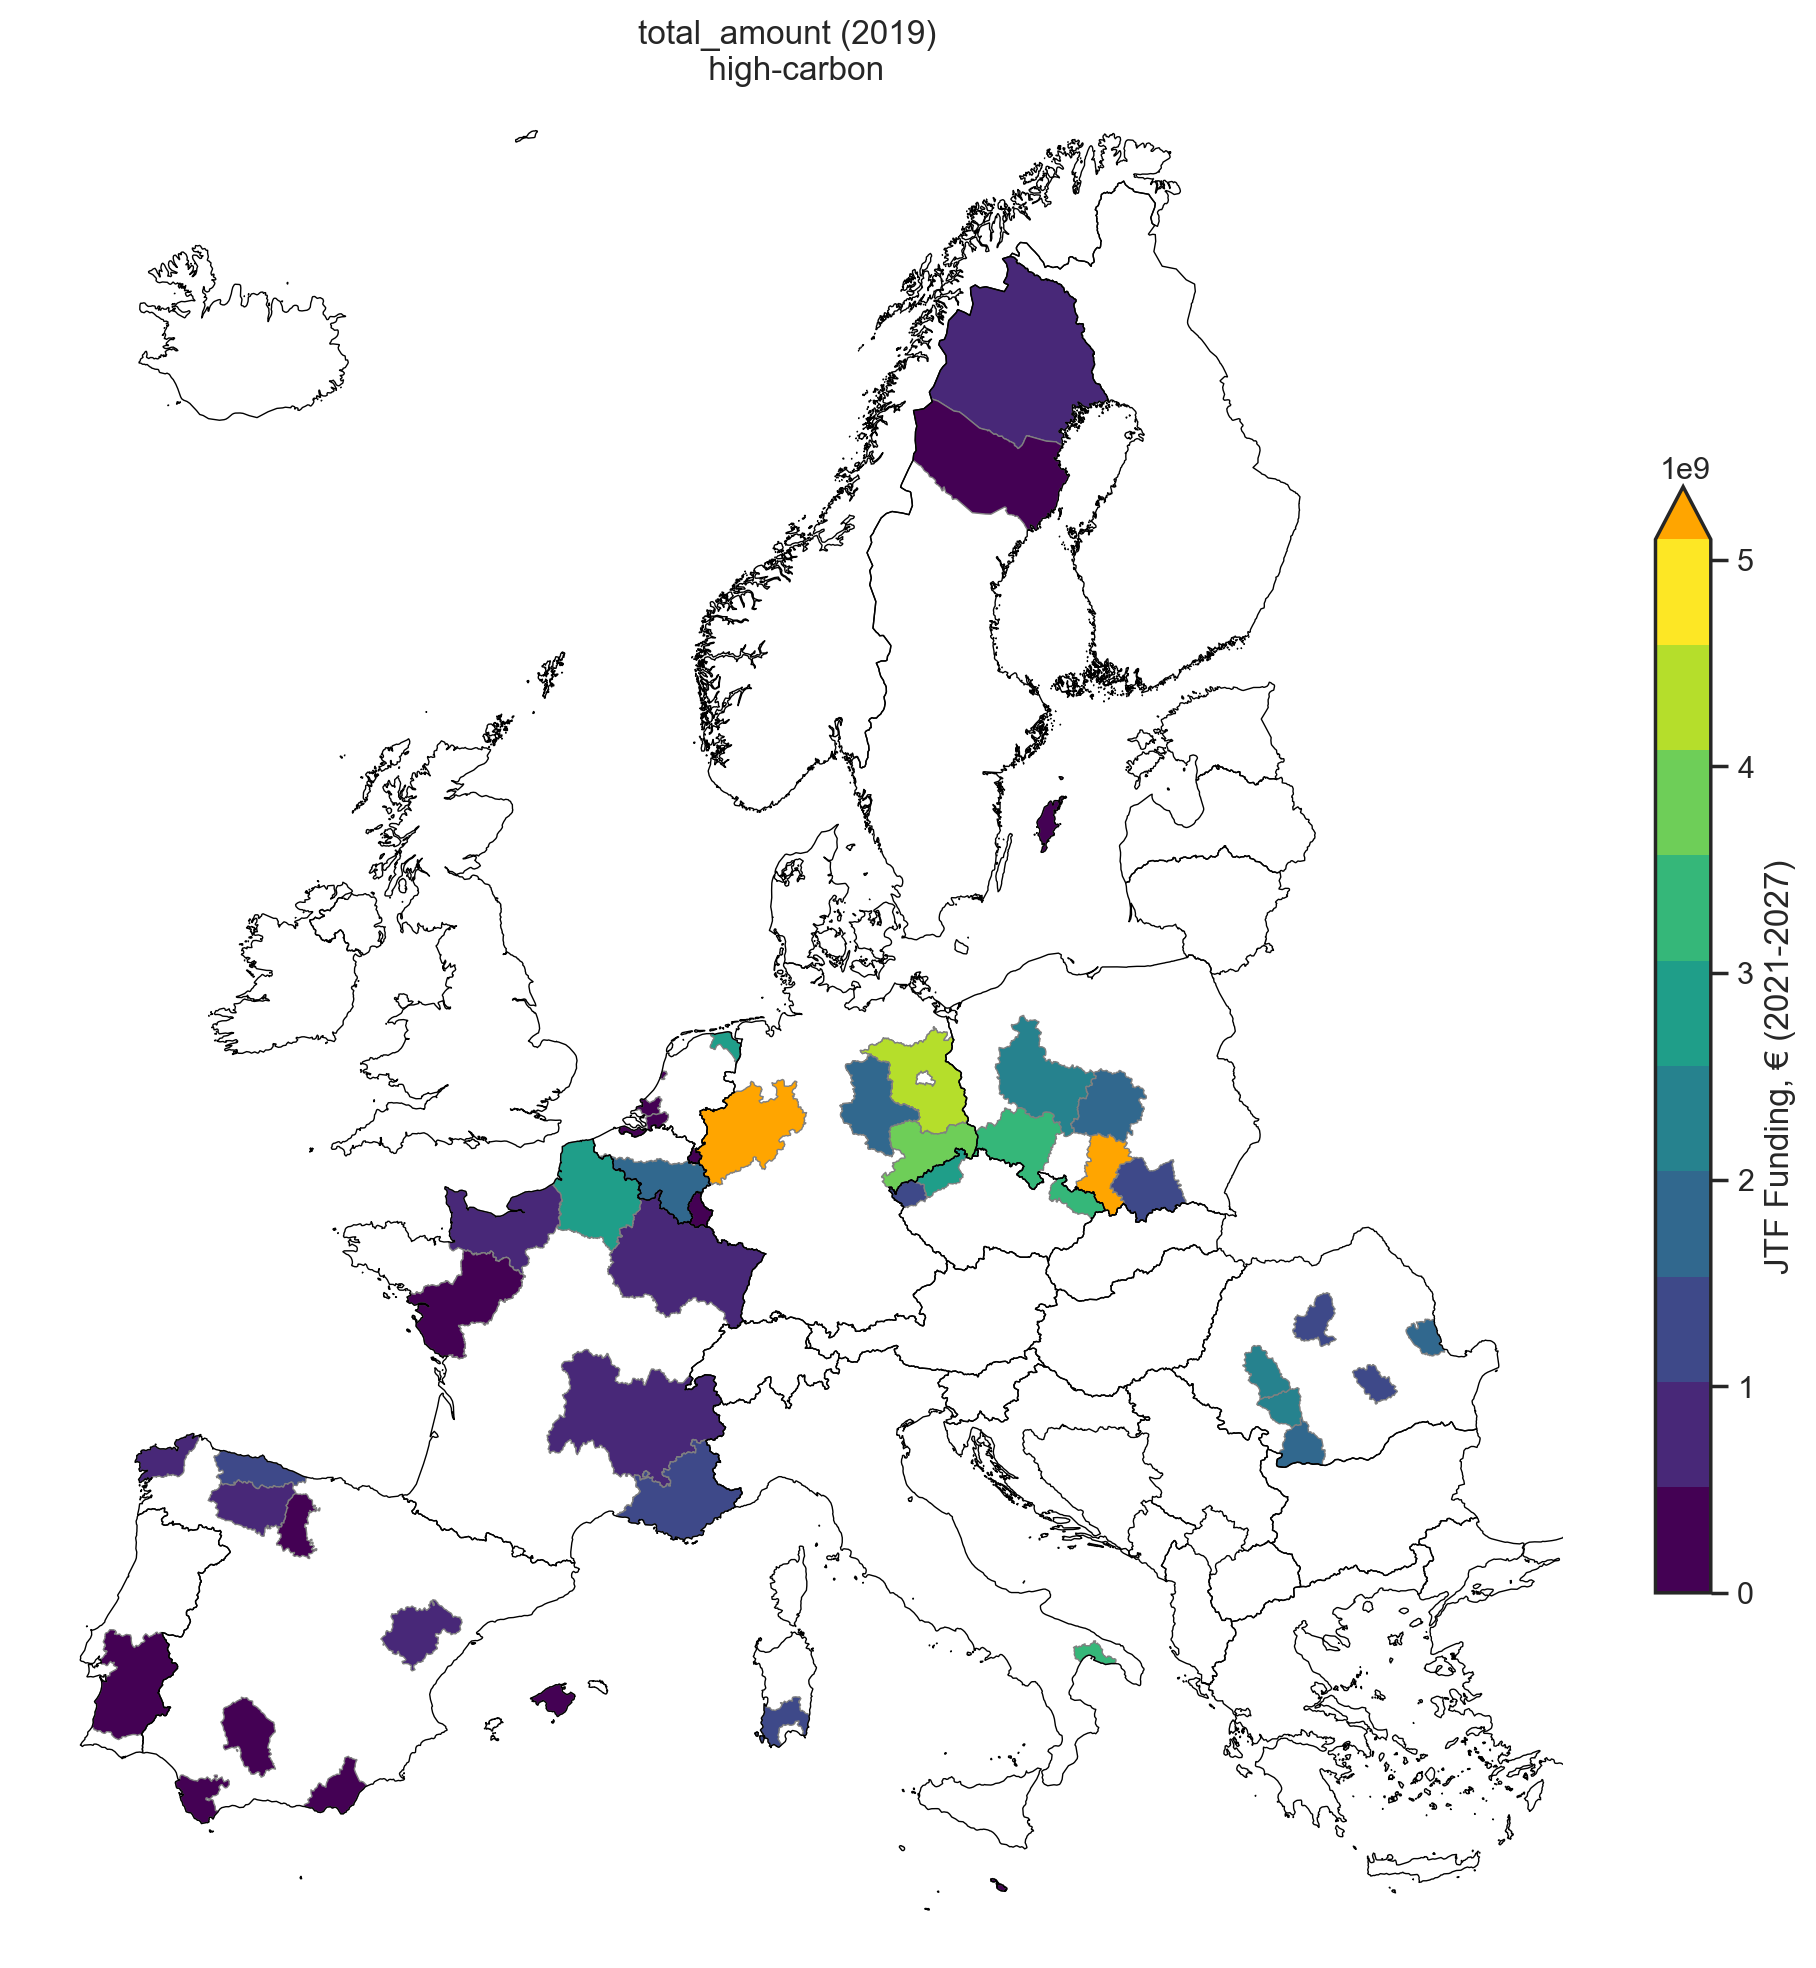

In [116]:
vis.plot_map(
    gdf_sub=gdf_regional_inv,
    cols_to_plot=['total_amount', 'country_amount', 'eu_amount'],
    save_data=False,
    out_dir=None,
    figsize=(10,7),
    cbar_label='JTF Funding, € (2021-2027)',
    legend='None',
    n_cats=10,
    cmap='viridis',
    vmin=0,
    #vmax=12500, # 50000
    cmap_set_over='orange',
    additional_title_info=category
)

#### Calculate country-level sums for the unmatched entries
-  We are definitely double counting investments: our sums are too large!
-  See https://cohesiondata.ec.europa.eu/stories/s/28yb-762c#more-information

In [97]:
national_inv_only = gdf_jtf_raw_2.loc[gdf_jtf_raw_2["region_final"].isna()]

In [98]:
list(national_inv_only.select_dtypes(include=[np.number]))

['total_amount', 'country_amount', 'eu_amount', 'LEVL_CODE']

In [100]:
national_inv_only.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\1799305866.py:1: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  national_inv_only.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\1799305866.py:1: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  national_inv_only.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})


,,total_amount,country_amount,eu_amount
ms,ms_name_en,,,
AT,Austria,"1,105,006,011.85","577,594,618.85","527,411,393.00"
CZ,Czechia,"154,493,366.01","23,174,006.01","131,319,360.00"
DK,Denmark,"697,516,672.00","348,758,336.00","348,758,336.00"
EE,Estonia,"2,267,975,381.97","893,224,435.97","1,374,750,946.00"
EL,Greece,"6,387,485,486.16","996,342,882.16","5,391,142,604.00"
ES,Spain,"195,055,996.54","60,066,403.54","134,989,593.00"
FI,Finland,"2,584,255,878.03","775,276,767.03","1,808,979,111.00"
FR,France,"1,788,776,410.20","588,485,491.20","1,200,290,919.00"
HR,Croatia,"849,527,396.47","127,429,109.47","722,098,287.00"


In [101]:
gdf_jtf_raw_2.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})

C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\3067727637.py:1: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  gdf_jtf_raw_2.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})
C:\Users\fzaussinger.D\AppData\Local\Temp\ipykernel_7720\3067727637.py:1: FutureWarning: The provided callable <function sum at 0x00000264C85DE840> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  gdf_jtf_raw_2.groupby(['ms', 'ms_name_en']).agg({'total_amount': np.sum, 'country_amount': np.sum, 'eu_amount': np.sum})


,,total_amount,country_amount,eu_amount
ms,ms_name_en,,,
AT,Austria,"1,105,006,011.85","577,594,618.85","527,411,393.00"
BE,Belgium,"1,773,382,407.50","1,064,029,444.50","709,352,963.00"
CY,Cyprus,"2,265,299,624.00","679,589,904.00","1,585,709,720.00"
CZ,Czechia,"7,570,174,926.25","1,135,526,254.25","6,434,648,672.00"
DE,Germany,"22,090,758,498.09","7,999,448,656.09","14,091,309,842.00"
DK,Denmark,"697,516,672.00","348,758,336.00","348,758,336.00"
EE,Estonia,"2,267,975,381.97","893,224,435.97","1,374,750,946.00"
EL,Greece,"6,387,485,486.16","996,342,882.16","5,391,142,604.00"
ES,Spain,"4,876,400,591.41","1,501,660,895.41","3,374,739,696.00"
